<a href="https://colab.research.google.com/github/RatchanonPa/Data-Warehouse-and-Big-Data-Analytics/blob/main/Thal_Group_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
pd.set_option("display.max_columns", None)

# Load data


In [60]:
train = pd.read_csv('/content/drive/MyDrive/bsc_dpdm24_data/train_set.csv')
train

,id number,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|,Thal_Group
0,67d169,25.0,11.1,34.0,78.0,3.2,0.0,55.9,4.358974,25.464706,32.647059,40.341026,18.141026,2.0,1.535294,3.070588,Abnormal_variants
1,67l168,32.0,13.9,42.0,86.0,3.7,0.3,54.8,5.197674,28.859060,33.557047,35.802326,5.802326,6.0,1.859060,11.154362,Abnormal_variants
2,67i267,43.0,10.1,31.0,78.0,2.6,0.3,56.2,3.974359,25.412903,32.580645,43.725641,23.525641,2.0,1.587097,3.174194,Abnormal_variants
3,67e248,33.0,12.9,38.0,76.0,3.0,0.2,61.2,5.000000,25.800000,33.947368,32.300000,6.500000,4.0,1.200000,4.800000,Abnormal_variants
4,67h277,23.0,12.9,40.0,78.0,3.1,0.0,55.6,5.128205,25.155000,32.250000,34.171795,8.371795,2.0,1.845000,3.690000,Abnormal_variants
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4317,66z431,63.0,10.1,31.0,83.0,2.8,1.8,84.2,3.734940,27.041935,32.580645,48.965060,28.765060,3.0,0.041935,0.125806,Normal
4318,66z436,19.0,11.1,34.0,79.0,2.6,0.6,78.0,4.303797,25.791176,32.647059,41.396203,19.196203,1.0,1.208824,1.208824,Normal
4319,66z439,80.0,10.9,33.9,79.0,3.0,0.2,87.2,4.291139,25.401180,32.153392,42.008861,20.208861,1.0,1.598820,1.598820,Normal
4320,66z445,27.0,13.2,41.4,87.0,2.9,0.3,87.6,4.758621,27.739130,31.884058,42.641379,16.241379,7.0,0.739130,5.173913,Normal


In [61]:
test = pd.read_csv('/content/drive/MyDrive/bsc_dpdm24_data/X_test.csv')
test

,id number,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|
0,66z133,38.0,12.4,37.00,78.0,2.7,1.3,75.4,4.743590,26.140541,33.513514,36.056410,11.256410,2.0,0.859459,1.718919
1,66z297,28.0,12.8,39.40,82.0,2.7,0.0,97.3,4.804878,26.639594,32.487310,38.795122,13.195122,2.0,0.360406,0.720812
2,66u491,78.0,10.9,33.90,79.0,3.1,0.0,96.9,4.291139,25.401180,32.153392,42.008861,20.208861,1.0,1.598820,1.598820
3,66x072,65.0,10.9,33.90,79.0,3.0,0.2,87.9,4.291139,25.401180,32.153392,42.008861,20.208861,1.0,1.598820,1.598820
4,67m031,17.0,11.5,36.00,78.0,2.8,0.8,79.6,4.615385,24.916667,31.944444,38.884615,15.884615,2.0,2.083333,4.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992,67j317,NaN,8.4,26.00,59.0,2.6,0.7,0.3,4.406780,19.061538,32.307692,29.393220,12.593220,21.0,7.938462,166.707692
1993,66a385,NaN,10.1,31.00,78.0,3.3,0.0,55.0,3.974359,25.412903,32.580645,43.725641,23.525641,2.0,1.587097,3.174194
1994,67g355,53.0,10.4,34.00,77.0,3.0,0.2,49.6,4.415584,23.552941,30.588235,41.384416,20.584416,3.0,3.447059,10.341176
1995,66s121,54.0,10.1,31.00,78.0,2.4,0.3,42.0,3.974359,25.412903,32.580645,43.725641,23.525641,2.0,1.587097,3.174194


# Preprocessing

In [11]:
print(train.shape)
print(train.columns)
train.duplicated().sum()

(4322, 17)
Index(['id number', 'Xn', 'Hb(Gm%)', 'Hct(%)', 'MCV(fl)', 'A2 (2-3%)',
       'HbF (2%)', 'HbA (95-97%)', 'RBC', 'MCH', 'MCHC', 'MCV-RBC-3*HGB',
       'MCV-RBC-5*HGB', '|80-MCV|', '|27-MCH|', '|80-MCV|*|27-MCH|',
       'Thal_Group'],
      dtype='object')


0

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322 entries, 0 to 4321
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id number          4322 non-null   object 
 1   Xn                 3887 non-null   float64
 2   Hb(Gm%)            4315 non-null   float64
 3   Hct(%)             4315 non-null   float64
 4   MCV(fl)            4315 non-null   float64
 5   A2 (2-3%)          4189 non-null   float64
 6   HbF (2%)           4206 non-null   float64
 7   HbA (95-97%)       4206 non-null   float64
 8   RBC                4315 non-null   float64
 9   MCH                4315 non-null   float64
 10  MCHC               4315 non-null   float64
 11  MCV-RBC-3*HGB      4315 non-null   float64
 12  MCV-RBC-5*HGB      4315 non-null   float64
 13  |80-MCV|           4315 non-null   float64
 14  |27-MCH|           4315 non-null   float64
 15  |80-MCV|*|27-MCH|  4315 non-null   float64
 16  Thal_Group         4322 

In [21]:
train.describe()

,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|
count,3887.000000,4315.000000,4315.000000,4315.000000,4189.000000,4206.000000,4206.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000
mean,40.510059,10.370717,32.448678,70.919177,11.530902,1.497967,80.268503,4.635384,22.654757,31.857088,34.924984,14.108856,10.002491,4.556300,72.895320
std,24.383982,1.997339,5.512625,9.471956,18.457527,5.985359,22.044018,0.789678,3.652130,1.543573,9.254880,10.762377,8.631753,3.427993,91.344636
min,0.000000,1.600000,3.700000,43.000000,0.000000,0.000000,0.000000,0.395062,8.703704,17.407407,4.967967,-20.333070,0.000000,0.000000,0.000000
25%,24.000000,9.400000,30.000000,64.000000,2.400000,0.000000,74.200000,4.291139,19.732143,30.947042,28.426374,7.420635,2.000000,1.598820,1.598820
50%,36.000000,10.700000,33.000000,73.000000,2.900000,0.400000,86.500000,4.605263,23.594248,32.153392,35.306897,12.894737,8.000000,3.654545,27.000000
75%,62.000000,11.350000,35.000000,79.000000,16.500000,1.100000,96.000000,5.079365,25.401180,32.727273,42.008861,20.208861,17.000000,7.267857,118.400000
max,97.000000,19.600000,53.100000,109.000000,100.000000,99.200000,118.900000,7.742601,36.364999,36.969697,83.949485,76.149485,43.000000,18.296296,548.888889


In [9]:
train.isnull().sum()

,0
id number,0
Xn,435
Hb(Gm%),7
Hct(%),7
MCV(fl),7
A2 (2-3%),133
HbF (2%),116
HbA (95-97%),116
RBC,7
MCH,7


In [12]:
set(train['Thal_Group'])

{'Abnormal_variants',
 'Alpha_thal_related',
 'Beta_thal_related',
 'Complex_genotypes',
 'HbE_related',
 'Normal'}

In [28]:
# prompt: map train['Thal_Group'] value {'Abnormal_variants': 5,
#                                                'Alpha_thal_related':4,
#                                                'Beta_thal_related': 3,
#                                                'Complex_genotypes': 2,
#                                                'HbE_related': 1,
#                                                'Normal': 0}

thal_mapping = {'Abnormal_variants': 5,
                'Alpha_thal_related': 4,
                'Beta_thal_related': 3,
                'Complex_genotypes': 2,
                'HbE_related': 1,
                'Normal': 0}

train['Thal_Group'] = train['Thal_Group'].map(thal_mapping)
print(train['Thal_Group'].unique())


[5 3 1 4 2 0]


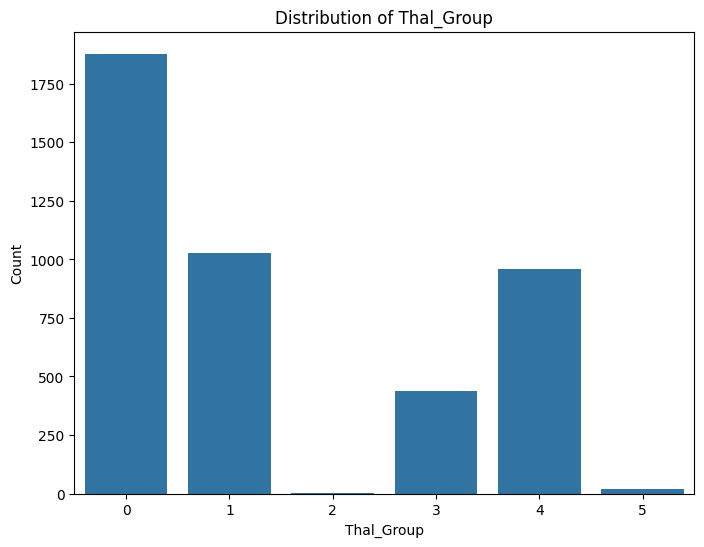

In [29]:
# prompt: visualize train['Thal_Group']

import matplotlib.pyplot as plt
# Visualize Thal_Group
plt.figure(figsize=(8, 6))
sns.countplot(x='Thal_Group', data=train)
plt.title('Distribution of Thal_Group')
plt.xlabel('Thal_Group')
plt.ylabel('Count')
plt.show()


In [19]:
# prompt: group by train['Thal_Group']

# Group data by 'Thal_Group'
grouped_thal = train.groupby('Thal_Group')

# Print some descriptive statistics for each group
grouped_thal.count()


,id number,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|
Thal_Group,,,,,,,,,,,,,,,,
Abnormal_variants,18,17,18,18,18,18,18,18,18,18,18,18,18,18,18,18
Alpha_thal_related,959,866,955,955,955,891,898,898,955,955,955,955,955,955,955,955
Beta_thal_related,439,397,438,438,438,432,434,434,438,438,438,438,438,438,438,438
Complex_genotypes,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
HbE_related,1025,942,1023,1023,1023,1021,1021,1021,1023,1023,1023,1023,1023,1023,1023,1023
Normal,1878,1662,1878,1878,1878,1824,1832,1832,1878,1878,1878,1878,1878,1878,1878,1878


In [20]:
grouped_thal.describe()

Xn                                                     \
                     count       mean        std  min   25%   50%   75%   max   
Thal_Group                                                                      
Abnormal_variants     17.0  40.529412  23.294628  3.0  31.0  39.0  43.0  88.0   
Alpha_thal_related   866.0  41.330254  25.740940  0.0  22.0  39.0  64.0  92.0   
Beta_thal_related    397.0  46.324937  28.496016  0.0  24.0  55.0  70.0  97.0   
Complex_genotypes      3.0  32.666667  34.645827  0.0  14.5  29.0  49.0  69.0   
HbE_related          942.0  35.488960  20.047084  0.0  23.0  32.0  43.0  90.0   
Normal              1662.0  41.553550  24.374397  0.0  25.0  39.0  63.0  97.0   

                   Hb(Gm%)                                                  \
                     count       mean       std  min     25%   50%     75%   
Thal_Group                                                                   
Abnormal_variants     18.0  11.105556  1.659366  8.4  10.100  10.6  12.575   
Alpha_thal_related   955.0   9.530366  1.662981  3.8   8.400   9.8  10.200   
Beta_thal_related    438.0   9.790970  1.190078  1.6   9.525  10.1  10.100   
Complex_genotypes      3.0   9.933333  2.309401  8.6   8.600   8.6  10.600   
HbE_related         1023.0  11.333333  1.973456  4.0  10.400  11.7  12.300   
Normal              1878.0  10.402556  2.081638  3.1   9.300  10.9  10.900   

                          Hct(%)                                          \
                     max   count       mean       std   min   25%    50%   
Thal_Group                                                                 
Abnormal_variants   13.9    18.0  33.650000  4.879398  26.0  31.0  31.85   
Alpha_thal_related  13.5   955.0  30.960775  4.937600  13.0  28.0  31.80   
Beta_thal_related   13.3   438.0  31.048630  3.558792   5.0  30.0  32.00   
Complex_genotypes   12.6     3.0  31.666667  6.350853  28.0  28.0  28.00   
HbE_related         16.1  1023.0  34.428353  5.665802  14.3  31.0  35.00   
Normal              19.6  1878.0  32.443184  5.747411   3.7  30.0  33.90   

                               MCV(fl)                                         \
                     75%   max   count       mean       std   min   25%   50%   
Thal_Group                                                                      
Abnormal_variants   37.0  42.0    18.0  79.625000  3.869422  71.0  78.0  78.0   
Alpha_thal_related  33.0  42.8   955.0  63.160471  6.012715  47.0  60.0  64.0   
Beta_thal_related   32.0  42.3   438.0  63.642123  4.023093  46.0  63.0  63.0   
Complex_genotypes   33.5  39.0     3.0  67.000000  1.732051  66.0  66.0  66.0   
HbE_related         37.0  49.1  1023.0  72.130499  8.779957  45.0  69.0  76.0   
Normal              33.9  53.1  1878.0  75.824814  8.563510  43.0  74.0  79.0   

                                 A2 (2-3%)                              \
                      75%    max     count       mean        std   min   
Thal_Group                                                               
Abnormal_variants   82.75   86.0      18.0   3.227778   0.425379   2.3   
Alpha_thal_related  66.00   88.0     891.0   6.374747  15.155143   0.0   
Beta_thal_related   63.00   81.0     432.0   5.626389   0.683480   2.1   
Complex_genotypes   67.50   69.0       3.0  21.166667   0.404145  20.8   
HbE_related         77.00   88.0    1021.0  34.582174  21.999893   5.7   
Normal              79.00  109.0    1824.0   2.610992   0.554732   0.5   

                                               HbF (2%)                       \
                       25%   50%    75%    max    count      mean        std   
Thal_Group                                                                     
Abnormal_variants    2.925   3.2   3.65    3.9     18.0  0.188889   0.234869   
Alpha_thal_related   1.750   2.4   2.70   82.0    898.0  2.888781   9.678496   
Beta_thal_related    5.300   5.6   6.00    8.3    434.0  3.213076  11.297123   
Complex_genotypes   20.950  2

In [43]:
# prompt: ตรวจสอบ correlationของ Thal_Group กับทุก feature ยกเว้น   id number

import matplotlib.pyplot as plt
# Calculate correlation between 'Thal_Group' and other features (excluding 'id')
correlation_thal = train.drop('id number', axis=1).corr()['Thal_Group']

# Display the correlation
print(correlation_thal)

# Visualize the correlation using a heatmap (optional)
plt.figure(figsize=(12, 10))
sns.heatmap(train.drop('id number', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


ValueError: could not convert string to float: 'Abnormal_variants'

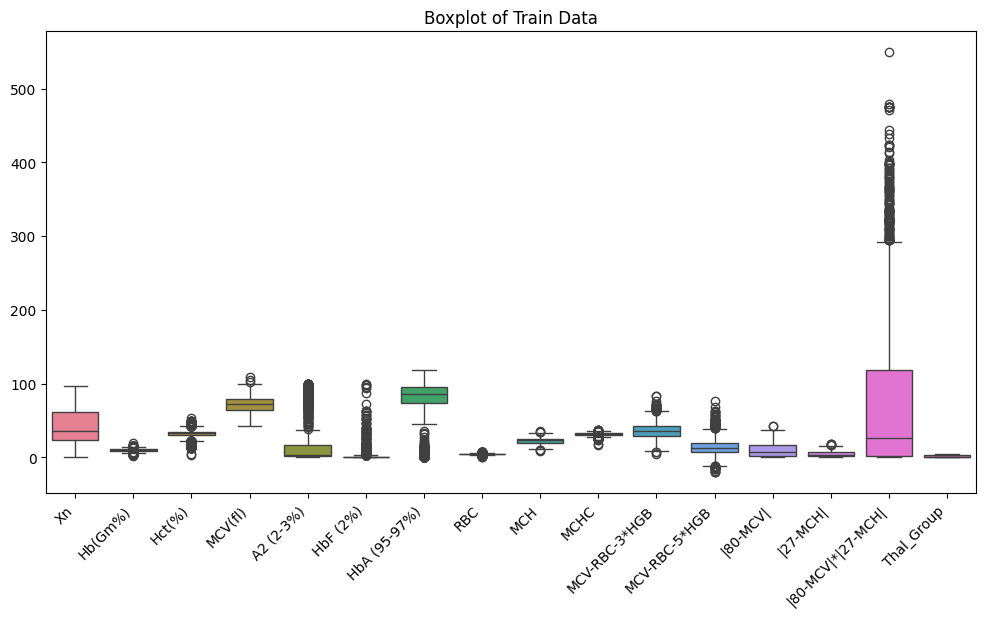

In [36]:
# prompt: plot boxplot of train

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.boxplot(data=train)
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot of Train Data')
plt.show()


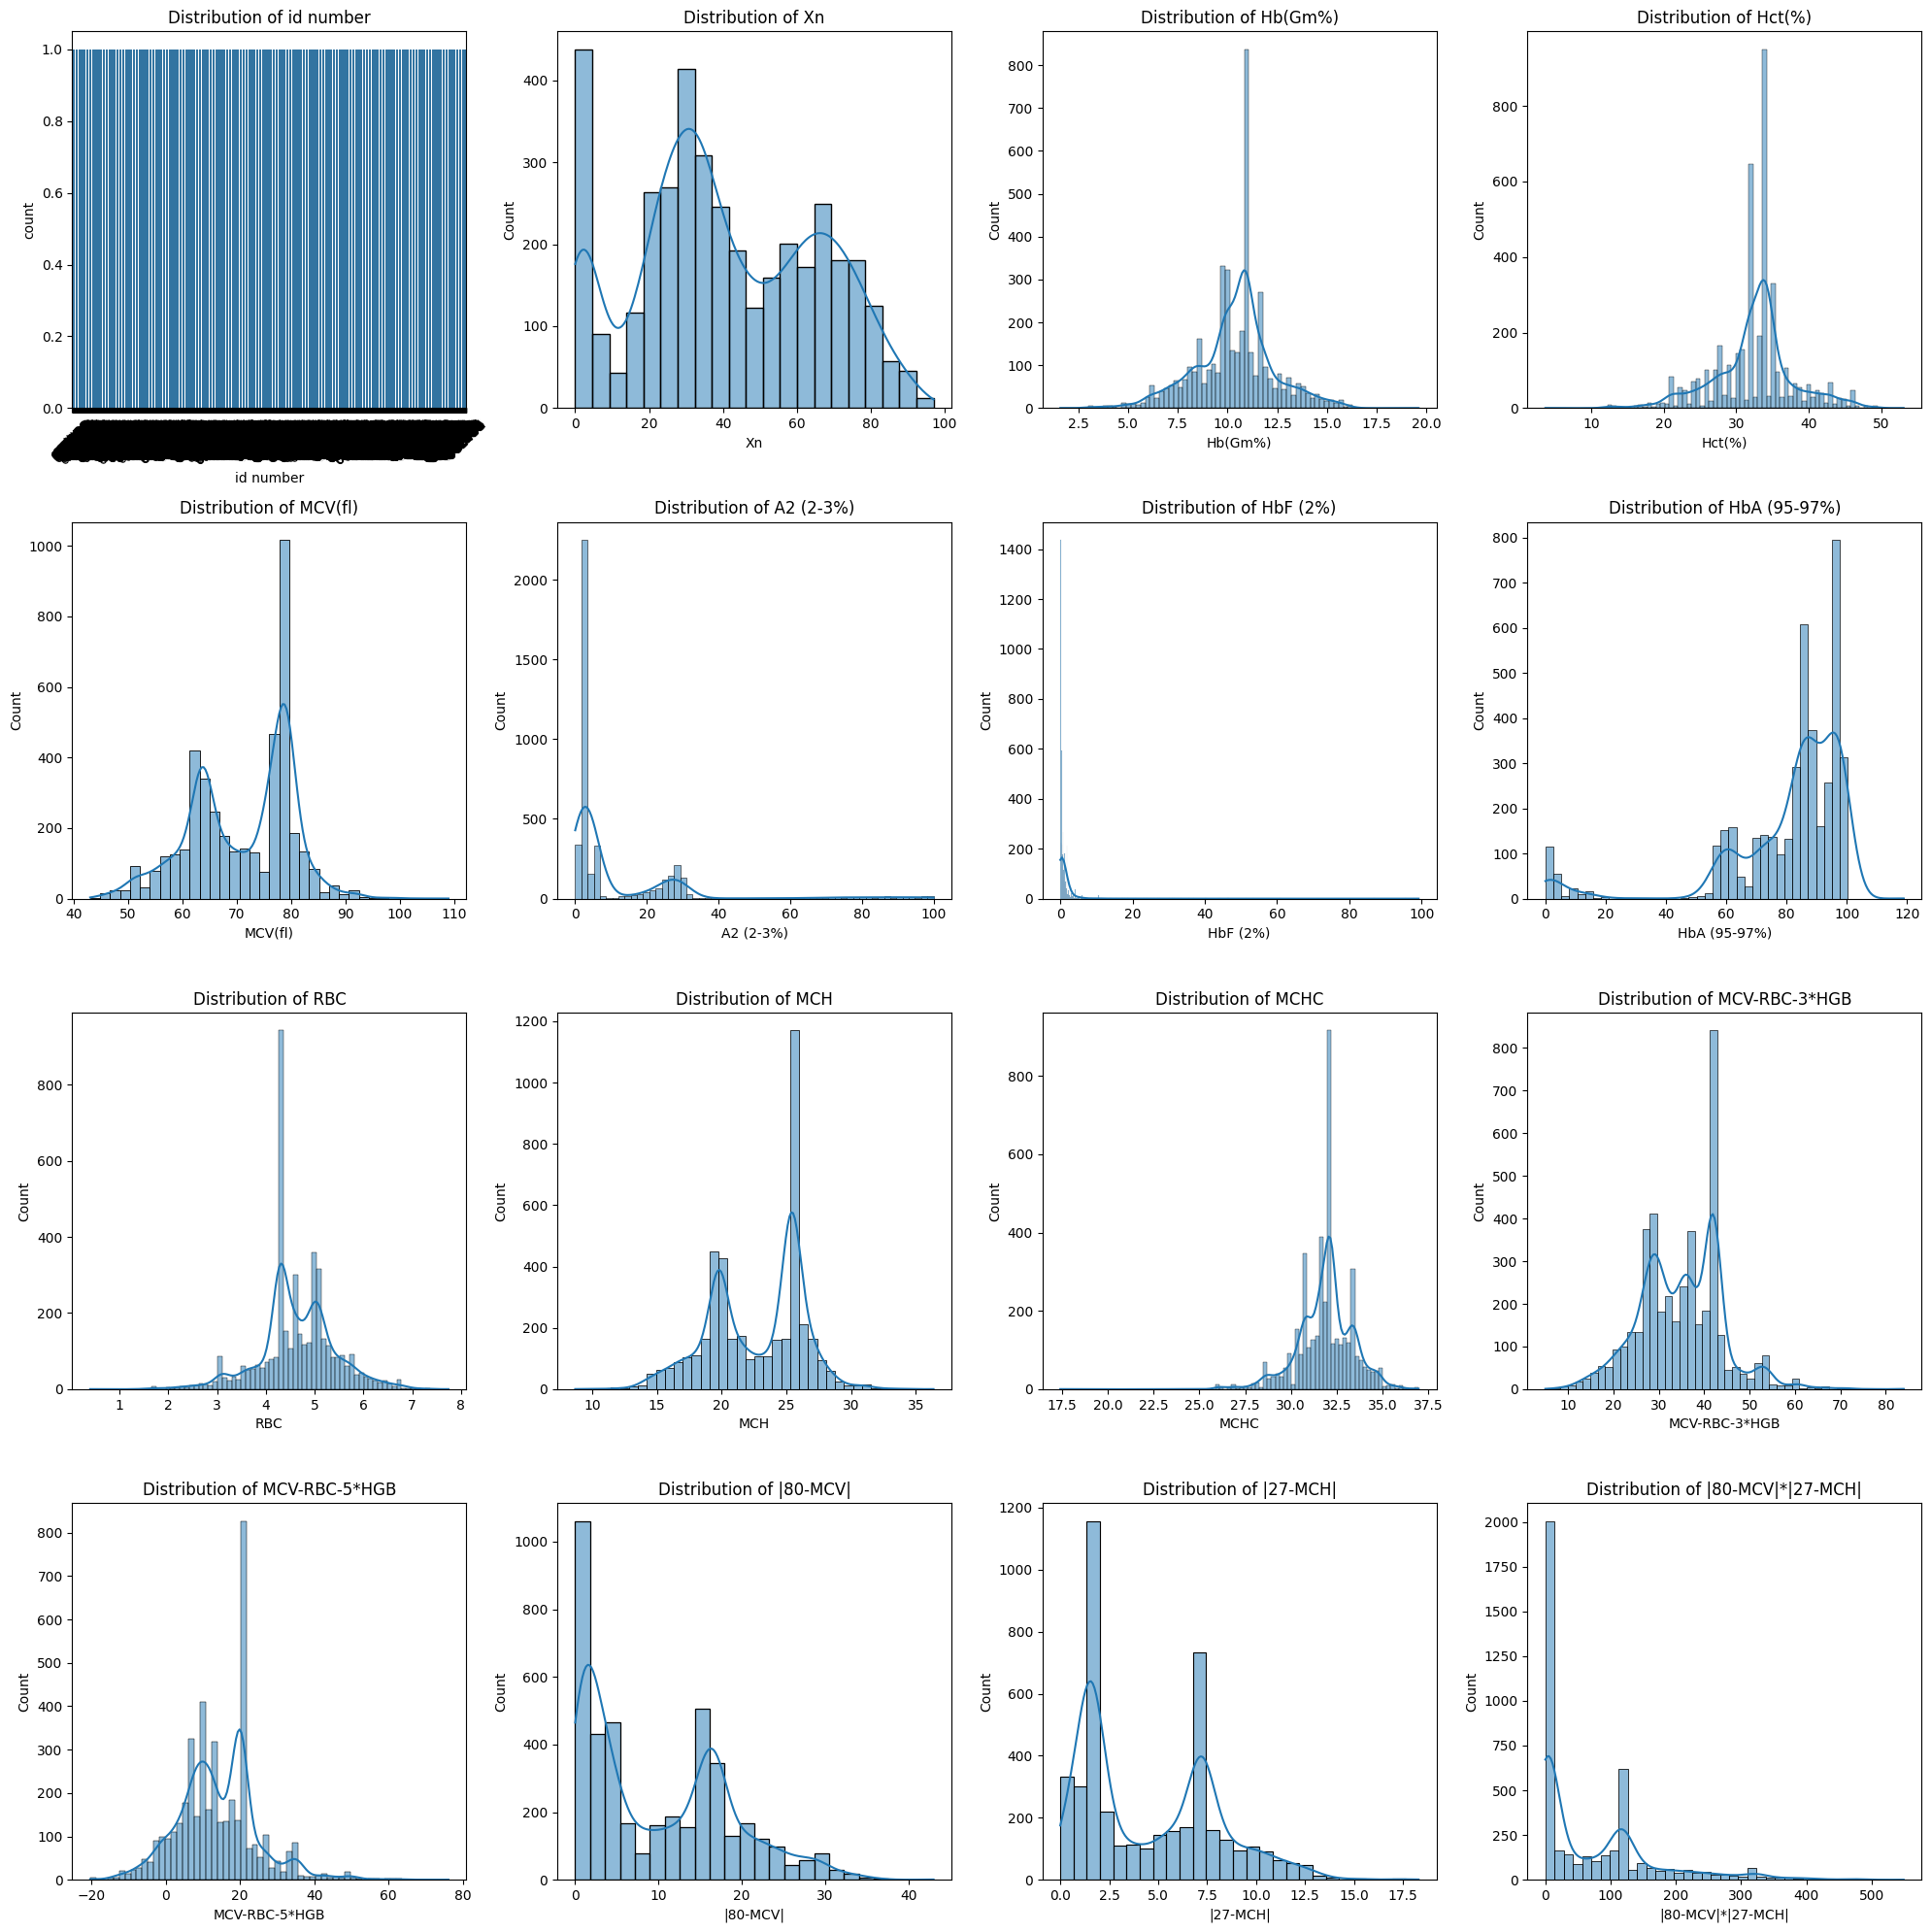

In [47]:
# prompt: plot distribution of train in 4x4 format

import matplotlib.pyplot as plt

# Assuming 'train' DataFrame is already loaded and preprocessed as in your provided code.

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, col in enumerate(train.columns[:16]): # Plotting only the first 16 columns in a 4x4 format
    if train[col].dtype in ['int64', 'float64']: # Check for numerical columns
        sns.histplot(train[col], ax=axes[i], kde=True) # Use histplot to visualize numerical columns
        axes[i].set_title(f'Distribution of {col}')
    else:
        sns.countplot(x=col, data=train, ax=axes[i]) # Use countplot for categorical columns
        axes[i].set_title(f'Distribution of {col}')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout() # Adjusts subplot parameters for a tight layout
plt.show()


In [62]:
X = train.drop(['id number', 'Thal_Group'], axis=1)
y = train['Thal_Group']
X_test = test.drop('id number', axis=1)

In [63]:
print(X.isnull().sum())  # เช็ค missing values
print(y.value_counts())  # ดู class distribution

Xn                   435
Hb(Gm%)                7
Hct(%)                 7
MCV(fl)                7
A2 (2-3%)            133
HbF (2%)             116
HbA (95-97%)         116
RBC                    7
MCH                    7
MCHC                   7
MCV-RBC-3*HGB          7
MCV-RBC-5*HGB          7
|80-MCV|               7
|27-MCH|               7
|80-MCV|*|27-MCH|      7
dtype: int64
Thal_Group
Normal                1878
HbE_related           1025
Alpha_thal_related     959
Beta_thal_related      439
Abnormal_variants       18
Complex_genotypes        3
Name: count, dtype: int64


# Real

In [2]:
# ====================
# 1. Import Libraries
# ====================
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE  # เปลี่ยนเป็น SMOTE ธรรมดา
from imblearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [47]:
# ====================
# 2. Load Data
# ====================
train = pd.read_csv('/content/drive/MyDrive/bsc_dpdm24_data/train_set.csv')
test = pd.read_csv('/content/drive/MyDrive/bsc_dpdm24_data/X_test.csv')

In [31]:
print(train.isnull().sum())
print(test.isnull().sum())

id number              0
Xn                   435
Hb(Gm%)                7
Hct(%)                 7
MCV(fl)                7
A2 (2-3%)            133
HbF (2%)             116
HbA (95-97%)         116
RBC                    7
MCH                    7
MCHC                   7
MCV-RBC-3*HGB          7
MCV-RBC-5*HGB          7
|80-MCV|               7
|27-MCH|               7
|80-MCV|*|27-MCH|      7
Thal_Group             0
dtype: int64
id number              0
Xn                   187
Hb(Gm%)                2
Hct(%)                 2
MCV(fl)                1
A2 (2-3%)             62
HbF (2%)              59
HbA (95-97%)          59
RBC                    2
MCH                    2
MCHC                   2
MCV-RBC-3*HGB          2
MCV-RBC-5*HGB          2
|80-MCV|               1
|27-MCH|               2
|80-MCV|*|27-MCH|      2
dtype: int64


In [48]:
# เติมค่า NaN ด้วย median สำหรับแต่ละคอลัมน์ที่เป็น float หรือ int ใน train
for col in train.columns:
    if train[col].isnull().any() and train[col].dtype in ['float64', 'int64']:
        median_val = train[col].median()  # คำนวณค่า median
        train[col].fillna(median_val, inplace=True)

print(train.isnull().sum())  # ตรวจสอบว่าค่า NaN หายไปหรือไม่

# เติมค่า NaN ด้วย median สำหรับแต่ละคอลัมน์ที่เป็น float หรือ int ใน test
for col in test.columns:
    if test[col].isnull().any() and test[col].dtype in ['float64', 'int64']:
        median_val = test[col].median()  # คำนวณค่า median
        test[col].fillna(median_val, inplace=True)

print(test.isnull().sum())  # ตรวจสอบว่าค่า NaN หายไปหรือไม่

id number            0
Xn                   0
Hb(Gm%)              0
Hct(%)               0
MCV(fl)              0
A2 (2-3%)            0
HbF (2%)             0
HbA (95-97%)         0
RBC                  0
MCH                  0
MCHC                 0
MCV-RBC-3*HGB        0
MCV-RBC-5*HGB        0
|80-MCV|             0
|27-MCH|             0
|80-MCV|*|27-MCH|    0
Thal_Group           0
dtype: int64
id number            0
Xn                   0
Hb(Gm%)              0
Hct(%)               0
MCV(fl)              0
A2 (2-3%)            0
HbF (2%)             0
HbA (95-97%)         0
RBC                  0
MCH                  0
MCHC                 0
MCV-RBC-3*HGB        0
MCV-RBC-5*HGB        0
|80-MCV|             0
|27-MCH|             0
|80-MCV|*|27-MCH|    0
dtype: int64


<ipython-input-48-cc80453ba1e1>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(median_val, inplace=True)
<ipython-input-48-cc80453ba1e1>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [49]:
# ====================
# 3. Preprocessing
# ====================

thal_mapping = {'Abnormal_variants': 5,
                'Alpha_thal_related': 4,
                'Beta_thal_related': 3,
                'Complex_genotypes': 2,
                'HbE_related': 1,
                'Normal': 0}

train['Thal_Group'] = train['Thal_Group'].map(thal_mapping)
print(train['Thal_Group'].unique())

# แยก features และ target
X = train.drop(['id number', 'Thal_Group'], axis=1)
y = train['Thal_Group']
X_test = test.drop('id number', axis=1)

# ตรวจสอบการกระจายคลาส
print("=== Class Distribution ===")
print(y.value_counts())

[5 3 1 4 2 0]
=== Class Distribution ===
Thal_Group
0    1878
1    1025
4     959
3     439
5      18
2       3
Name: count, dtype: int64


In [51]:
from imblearn.over_sampling import SMOTE

# ใช้ SMOTE เพิ่มตัวอย่างของคลาสที่มีจำนวนน้อย
smote = SMOTE(random_state=42, k_neighbors=2)  # ตั้งค่า k_neighbors ให้เหมาะสม
X_smote, y_smote = smote.fit_resample(X, y)

# แสดงจำนวนตัวอย่างในแต่ละคลาสก่อน-หลังทำ SMOTE
print("Before SMOTE:")
print(y.value_counts())
print("After SMOTE:")
print(pd.Series(y_smote).value_counts())


Before SMOTE:
Thal_Group
0    1878
1    1025
4     959
3     439
5      18
2       3
Name: count, dtype: int64
After SMOTE:
Thal_Group
5    1878
3    1878
1    1878
4    1878
2    1878
0    1878
Name: count, dtype: int64


In [52]:
# ปรับสเกลข้อมูล
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_smote)
X_test_scaled = scaler.transform(X_test)

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define Stratified K-fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=6)

In [42]:
# Define Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)  # default

# Train & evaluate (cross-validation)
dt_cv_scores = cross_val_score(dt_classifier, X_scaled, y_smote, cv=skf, scoring='f1_macro')

# Print the cross-validation scores
print(f"Cross-validation scores: {dt_cv_scores}")
print(f"Mean f1_macro: {dt_cv_scores.mean()}")
print("Standard deviation of cross-validation scores:", dt_cv_scores.std())

Cross-validation scores: [0.96544448 0.97077642 0.96896688 0.96808085 0.97074388 0.9589189
 0.95903927 0.97163613 0.9715121  0.96878467]
Mean f1_macro: 0.9673903570994733
Standard deviation of cross-validation scores: 0.004559890452111111


In [20]:
# Define Decision Tree classifier
sdt_classifier = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)  # default

# Train & evaluate (cross-validation)
sdt_cv_scores = cross_val_score(sdt_classifier, X, y, cv=skf, scoring='f1_macro')

# Print the cross-validation scores
print(f"Cross-validation scores: {sdt_cv_scores}")
print(f"Mean f1_macro: {sdt_cv_scores.mean()}")
print("Standard deviation of cross-validation scores:", sdt_cv_scores.std())

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


Cross-validation scores: [0.70183208 0.72619416 0.69951023 0.60775373 0.74833909 0.91015209
 0.75119952 0.87691051 0.81642334 0.7681293 ]
Mean f1_macro: 0.7606444055840852
Standard deviation of cross-validation scores: 0.08428342122174409


In [21]:
# Define Support Vector Machine classifier
svm_classifier = SVC(class_weight='balanced', probability=True)

# Train & evaluate (cross-validation)
svm_cv_scores = cross_val_score(svm_classifier, X, y, cv=skf, scoring='f1_macro')

# Print the cross-validation scores
print(f"Cross-validation scores: {svm_cv_scores}")
print(f"Mean f1_macro: {svm_cv_scores.mean()}")
print("Standard deviation of cross-validation scores:", svm_cv_scores.std())

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


Cross-validation scores: [0.62829132 0.59778525 0.56869919 0.54757546 0.56489819 0.5456935
 0.56875458 0.66154205 0.57227095 0.57288103]
Mean f1_macro: 0.5828391506269159
Standard deviation of cross-validation scores: 0.03469553484536524


In [163]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define classifiers
rf_classifier = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train & evaluate RandomForest (cross-validation)
rf_cv_scores = cross_val_score(rf_classifier, X, y, cv=skf, scoring='f1_macro')
print(f"RandomForest Cross-validation scores: {rf_cv_scores}")
print(f"Mean f1_macro (RandomForest): {rf_cv_scores.mean()}")
print(f"Standard deviation: {rf_cv_scores.std()}")


RandomForest Cross-validation scores: [0.87702926 0.79496204 0.79476617 0.63266494 0.95651593 0.74683322
 0.74469714 0.95769345 0.94949152 0.95500674]
Mean f1_macro (RandomForest): 0.8409660408544122
Standard deviation: 0.10900895089650203


ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py", line 1599, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/train

In [ ]:
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# คำนวณค่า scale_pos_weight
counter = Counter(y)
scale_pos_weight = counter[0] / counter[1]  # ถ้าคลาส 1 น้อยกว่าคลาส 0

# กำหนด XGBoost classifier พร้อม class balancing
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric="logloss",
                               tree_method="hist", scale_pos_weight=scale_pos_weight)

# Train & evaluate (cross-validation)
xgb_cv_scores = cross_val_score(xgb_classifier, X, y, cv=skf, scoring='f1_macro')

# Print results
print(f"XGBoost Cross-validation scores: {xgb_cv_scores}")
print(f"Mean f1_macro (XGBoost): {xgb_cv_scores.mean()}")
print(f"Standard deviation of cross-validation scores: {xgb_cv_scores.std()}")

In [90]:
# ====================
# 5. Model Selection
# ====================
models = {
    'XGBoost': XGBClassifier(tree_method='gpu_hist', eval_metric='mlogloss'),
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'SVM': SVC(class_weight='balanced', probability=True),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
    'ShortDecisionTree': DecisionTreeClassifier(class_weight='balanced', max_depth=5)
}

cv = StratifiedKFold(n_splits=5, shuffle=True)
results = {}

for name, model in models.items():
    pipeline = create_pipeline(model)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro')
    results[name] = {
        'mean_f1': np.mean(scores),
        'std_f1': np.std(scores)
    }

# แสดงผลลัพธ์
print("=== Model Comparison ===")
for model, metrics in results.items():
    print(f"{model}: F1 Macro = {metrics['mean_f1']:.3f} ± {metrics['std_f1']:.3f}")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **last_step_params["fit"])
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  

In [ ]:



# ====================
# 6. Hyperparameter Tuning
# ====================
best_model_name = max(results, key=lambda k: results[k]['mean_f1'])
print(f"\nBest Model: {best_model_name}")

param_grid = {
    'XGBoost': {
        'model__n_estimators': [300, 500],
        'model__max_depth': [5, 7],
        'model__learning_rate': [0.05, 0.1]
    },
    'RandomForest': {
        'model__n_estimators': [200, 300],
        'model__max_depth': [10, 15]
    },
    'SVM': {
        'model__C': [0.1, 1.0],
        'model__gamma': ['scale', 'auto']
    },
    'DecisionTree': {
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },
    'ShortDecisionTree': {
        'model__max_depth': [3, 5, 7],
        'model__min_samples_leaf': [1, 2, 4]
    }
}

pipeline = create_pipeline(models[best_model_name])
grid = GridSearchCV(
    pipeline,
    param_grid[best_model_name],
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)
grid.fit(X, y)

print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best F1 Macro: {grid.best_score_:.3f}")

# ====================
# 7. Final Prediction
# ====================
best_model = grid.best_estimator_
test_pred = best_model.predict(X_test)

# บันทึกผลลัพธ์
output = pd.DataFrame({'Thal_Group': test_pred})
output.to_csv('y_pred_final.csv', index=False)
print("\n=== Prediction Saved ===")